# Profit Prediction Model

In this notebook we train a machine learning model to predict profit using engineered features from the Superstore dataset.

The goals are:

• Predict profit using past order data

• Evaluate performance of the model

• Identify the drivers of profitability

This model will be used to support a discount optimization system.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Load Processed Dataset

In [2]:
df_model = pd.read_csv("../data/processed/superstore_model.csv")

In [3]:
df_model.head()

,Sales,Quantity,Discount,Shipping Time,Month,Year,Day Of Week,Unit Price,Item Price,Value Per Item,...,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Region_East,Region_South,Region_West
0,261.9600,2,0.00,3,11,2016,1,130.9800,130.9800,130.9800,...,False,False,False,False,False,False,False,False,True,False
1,731.9400,3,0.00,3,11,2016,1,243.9800,243.9800,243.9800,...,False,False,False,False,False,False,False,False,True,False
2,14.6200,2,0.00,4,6,2016,6,7.3100,7.3100,7.3100,...,True,False,False,False,False,False,False,False,False,True
3,957.5775,5,0.45,7,10,2015,6,191.5155,191.5155,191.5155,...,False,False,False,False,False,False,True,False,True,False
4,22.3680,2,0.20,7,10,2015,6,11.1840,11.1840,11.1840,...,False,False,False,False,True,False,False,False,True,False


## Handle Outliers

In [4]:
Q1 = df_model["Profit"].quantile(0.25)
Q3 = df_model["Profit"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_model = df_model[
    (df_model["Profit"] >= lower) &
    (df_model["Profit"] <= upper)
]

In [5]:
df_model.shape

(8113, 38)

## Log Transform Sales

In [6]:
df_model["Log Sales"] = np.log1p(df_model["Sales"])

In [7]:
df_model = df_model.drop("Sales", axis=1)

## Feature Interaction

In [8]:
df_model["Discount Sales Interaction"] = (
    df_model["Discount"] * df_model["Log Sales"]
)

## Split Dataset

In [9]:
X = df_model.drop("Profit", axis=1)
y = df_model["Profit"]

In [10]:
X.shape, y.shape

((8113, 38), (8113,))

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
X_train.shape, X_test.shape

((6490, 38), (1623, 38))

## Train Model

In [13]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


## Predictions

In [14]:
predictions = model.predict(X_test)

## Model Evaluation

In [15]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 9.955606602916122
R²: 0.7302729143993808


## Feature Importance

In [16]:
importances = model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

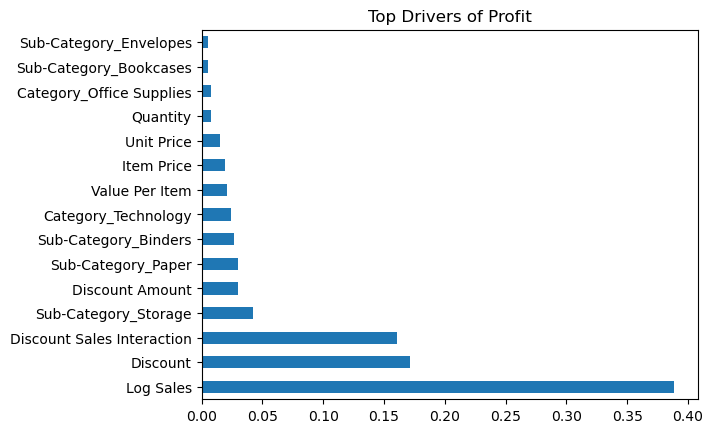

In [17]:
feature_importance.head(15).plot(kind="barh")

plt.title("Top Drivers of Profit")

plt.savefig("../outputs/charts/feature_importance.png")

plt.show()

## Summary of Model

After removing extreme outliers, applying feature transformations and introducing interaction features the model performance improved substantially compared to the original approach taken using RandomForestRegressor.

The final Gradient Boosting model achieves:

• RMSE ≈ 10  
• R² ≈ 0.73

Feature importance analysis shows that: 

• Sales Volume (Log Sales) is the single most dominant predictor.

• Pricing & Discounts are the next most important predictors.

The next stage of the project is to build a system that strategizes discount levels to maximize profit.

## Save Model

In [18]:
import joblib

joblib.dump(model, "../models/profit_model.pkl")

['../models/profit_model.pkl']